# 🏆 Churn Prediction — Part 2: Gradient Boosting Models
## XGBoost + LightGBM + CatBoost (Default Parameters)

**Goal:** Train 3 gradient boosting models with solid default parameters.  
These are the **core models** that will carry our final score.

| Model | Creator | Speed | Strength |
|-------|---------|-------|----------|
| XGBoost | DMLC | Fast | Industry standard, great regularization |
| LightGBM | Microsoft | Fastest | Best for large data, leaf-wise growth |
| CatBoost | Yandex | Slowest | Best out-of-box, ordered boosting |

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`  
**Output:** `part2_oof_*.npy`, `part2_test_*.npy`, feature importance


In [4]:
!pip install xgboost lightgbm catboost optuna --quiet


[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import xgboost
print(xgboost.__version__)  # Should work now

3.2.0


In [12]:
import xgboost
import lightgbm
import catboost
import optuna



In [14]:
import pandas as pd, numpy as np, time, warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
warnings.filterwarnings('ignore')

X_train = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/X_train.csv')
X_test = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/X_test.csv')
y_train = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/y_train.csv').squeeze()
test_ids = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/test_ids.csv').squeeze()

N_FOLDS = 5
SEED = 42
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
SPW = (y_train == 0).sum() / (y_train == 1).sum()  # 3.44

print(f"Data: {X_train.shape[0]:,} × {X_train.shape[1]} | scale_pos_weight: {SPW:.2f}")


Data: 594,194 × 71 | scale_pos_weight: 3.44


In [15]:
# Universal CV function
def run_cv(name, train_fn, X, y, X_test, skf, n_folds=N_FOLDS):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    scores = []
    t0 = time.time()
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        model = train_fn(X_tr, y_tr, X_va, y_va)
        oof[va_idx] = model.predict_proba(X_va)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / n_folds
        fold_auc = roc_auc_score(y_va, oof[va_idx])
        scores.append(fold_auc)
        print(f"  Fold {fold+1}: AUC = {fold_auc:.6f}")
    mean_auc = np.mean(scores)
    print(f"  ✅ {name}: {mean_auc:.6f} ± {np.std(scores):.6f} ({time.time()-t0:.1f}s)")
    return oof, test_preds, mean_auc, model  # return last model for feature importance


## XGBoost
Key params: `learning_rate=0.03` (slow learning, more trees = better generalization),  
`max_depth=6`, `subsample=0.8`, `colsample_bytree=0.8` (randomization reduces overfitting)


In [16]:
# ============================================================
# XGBOOST
# ============================================================
def train_xgb(X_tr, y_tr, X_va, y_va):
    m = xgb.XGBClassifier(
        n_estimators=2000, learning_rate=0.03,
        max_depth=6, min_child_weight=10,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=SPW,
        eval_metric='auc', tree_method='hist',
        early_stopping_rounds=100,
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    print(f"    (best iteration: {m.best_iteration})")
    return m

print("▶ XGBOOST")
oof_xgb, test_xgb, score_xgb, model_xgb = run_cv("XGB", train_xgb, X_train, y_train, X_test, skf)


▶ XGBOOST
    (best iteration: 885)
  Fold 1: AUC = 0.915954
    (best iteration: 1132)
  Fold 2: AUC = 0.916897
    (best iteration: 993)
  Fold 3: AUC = 0.916490
    (best iteration: 1180)
  Fold 4: AUC = 0.917553
    (best iteration: 813)
  Fold 5: AUC = 0.914738
  ✅ XGB: 0.916326 ± 0.000951 (307.2s)


## LightGBM
Key difference: `num_leaves=31` controls complexity instead of `max_depth`.  
`learning_rate=0.03` — same slow learning strategy. Fastest of the 3.


In [17]:
# ============================================================
# LIGHTGBM
# ============================================================
def train_lgb(X_tr, y_tr, X_va, y_va):
    m = lgb.LGBMClassifier(
        n_estimators=2000, learning_rate=0.03,
        num_leaves=31, max_depth=-1,
        min_child_samples=20,
        subsample=0.8, colsample_bytree=0.8, subsample_freq=1,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=SPW,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    print(f"    (best iteration: {m.best_iteration_})")
    return m

print("\n▶ LIGHTGBM")
oof_lgb, test_lgb, score_lgb, model_lgb = run_cv("LGB", train_lgb, X_train, y_train, X_test, skf)



▶ LIGHTGBM
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[55]	valid_0's binary_logloss: 0.365466
    (best iteration: 55)
  Fold 1: AUC = 0.911207
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[52]	valid_0's binary_logloss: 0.366423
    (best iteration: 52)
  Fold 2: AUC = 0.912056
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[55]	valid_0's binary_logloss: 0.36479
    (best iteration: 55)
  Fold 3: AUC = 0.911873
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[55]	valid_0's binary_logloss: 0.362745
    (best iteration: 55)
  Fold 4: AUC = 0.912813
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[52]	valid_0's binary_logloss: 0.36692
    (best iteration: 52)
  Fold 5: AUC = 0.910161
  ✅ LGB: 0.911622 ± 0.000892 (35.2s)


## CatBoost
Ordered boosting + automatic class weight handling.  
Typically gives the best single-model score with minimal tuning.


In [20]:
import time

# Take first fold from your SKF
train_idx, val_idx = next(iter(skf.split(X_train, y_train)))
X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

start = time.time()
m = CatBoostClassifier(
    iterations=2000, learning_rate=0.03,
    depth=6, l2_leaf_reg=3,
    subsample=0.8,
    auto_class_weights='Balanced',
    eval_metric='AUC', early_stopping_rounds=100,
    random_seed=SEED, verbose=100
)
m.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=100)
elapsed = time.time() - start

n_folds = skf.get_n_splits()
print(f"\n1 fold time: {elapsed/60:.1f} min")
print(f"Total estimated ({n_folds} folds): {elapsed * n_folds / 60:.1f} min")

0:	test: 0.8884446	best: 0.8884446 (0)	total: 79.1ms	remaining: 2m 38s
100:	test: 0.9117695	best: 0.9117695 (100)	total: 11.2s	remaining: 3m 31s


KeyboardInterrupt: 

In [21]:
# ============================================================
# CATBOOST
# ============================================================
def train_cb(X_tr, y_tr, X_va, y_va):
    m = CatBoostClassifier(
        iterations=2000, learning_rate=0.03,
        depth=6, l2_leaf_reg=3,
        subsample=0.8,
        auto_class_weights='Balanced',
        eval_metric='AUC', early_stopping_rounds=100,
        random_seed=SEED, verbose=0
    )
    m.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
    print(f"    (best iteration: {m.best_iteration_})")
    return m

print("\n▶ CATBOOST")
oof_cb, test_cb, score_cb, model_cb = run_cv("CB", train_cb, X_train, y_train, X_test, skf)



▶ CATBOOST
    (best iteration: 1999)
  Fold 1: AUC = 0.915791
    (best iteration: 1999)
  Fold 2: AUC = 0.916843
    (best iteration: 1999)
  Fold 3: AUC = 0.916422
    (best iteration: 1999)
  Fold 4: AUC = 0.917346
    (best iteration: 1997)
  Fold 5: AUC = 0.914690
  ✅ CB: 0.916218 ± 0.000919 (1108.3s)


In [22]:
# ============================================================
# QUICK ENSEMBLE (boost-only average)
# ============================================================
oof_boost_avg = (oof_xgb + oof_lgb + oof_cb) / 3
test_boost_avg = (test_xgb + test_lgb + test_cb) / 3
score_boost_avg = roc_auc_score(y_train, oof_boost_avg)

print("\n" + "=" * 55)
print("  PART 2 RESULTS")
print("=" * 55)
print(f"  XGBoost:              {score_xgb:.6f}")
print(f"  LightGBM:             {score_lgb:.6f}")
print(f"  CatBoost:             {score_cb:.6f}")
print(f"  Boost Average (3):    {score_boost_avg:.6f}")
print(f"\n  Quick submission with boost average:")

# Save predictions
np.save('part2_oof_xgb.npy', oof_xgb)
np.save('part2_oof_lgb.npy', oof_lgb)
np.save('part2_oof_cb.npy', oof_cb)
np.save('part2_test_xgb.npy', test_xgb)
np.save('part2_test_lgb.npy', test_lgb)
np.save('part2_test_cb.npy', test_cb)

# Quick submission
sub = pd.DataFrame({'id': test_ids, 'Churn': test_boost_avg})
sub.to_csv('submission_part2_boost_avg.csv', index=False)
print(f"  ✅ Saved: submission_part2_boost_avg.csv")
print(f"  ✅ Saved: part2_oof_*.npy, part2_test_*.npy")



  PART 2 RESULTS
  XGBoost:              0.916326
  LightGBM:             0.911622
  CatBoost:             0.916218
  Boost Average (3):    0.915993

  Quick submission with boost average:
  ✅ Saved: submission_part2_boost_avg.csv
  ✅ Saved: part2_oof_*.npy, part2_test_*.npy


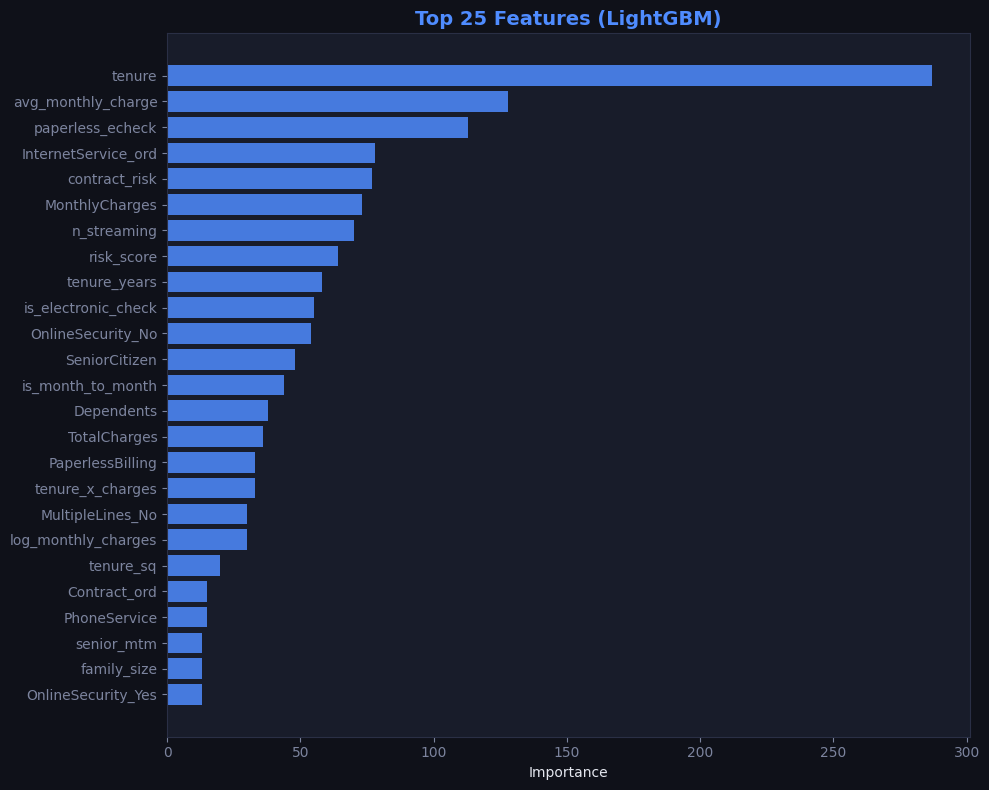


Top 15:
   1. tenure                            287
   2. avg_monthly_charge                128
   3. paperless_echeck                  113
   4. InternetService_ord                78
   5. contract_risk                      77
   6. MonthlyCharges                     73
   7. n_streaming                        70
   8. risk_score                         64
   9. tenure_years                       58
  10. is_electronic_check                55
  11. OnlineSecurity_No                  54
  12. SeniorCitizen                      48
  13. is_month_to_month                  44
  14. Dependents                         38
  15. TotalCharges                       36


In [23]:
# ============================================================
# FEATURE IMPORTANCE (LightGBM — fastest model)
# ============================================================
import matplotlib.pyplot as plt

imp = pd.DataFrame({'feature': X_train.columns, 'importance': model_lgb.feature_importances_})
imp = imp.sort_values('importance', ascending=True).tail(25)

plt.rcParams.update({'figure.facecolor': '#0f1119', 'axes.facecolor': '#181c2a',
    'text.color': '#e4e7ef', 'axes.labelcolor': '#e4e7ef',
    'xtick.color': '#7c849e', 'ytick.color': '#7c849e', 'axes.edgecolor': '#2a2f45'})

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp['feature'], imp['importance'], color='#4f8cff', alpha=0.85)
ax.set_title('Top 25 Features (LightGBM)', fontweight='bold', fontsize=14, color='#4f8cff')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

imp_full = pd.DataFrame({'feature': X_train.columns, 'importance': model_lgb.feature_importances_})
imp_full = imp_full.sort_values('importance', ascending=False)
imp_full.to_csv('feature_importance_lgb.csv', index=False)
print("\nTop 15:")
for i, (_, r) in enumerate(imp_full.head(15).iterrows(), 1):
    print(f"  {i:>2}. {r['feature']:<30} {r['importance']:>6.0f}")
